# 08 | Swin Transformer transfer learning

## Bainite–Martensite classification under two evaluation protocols

This notebook evaluates an ImageNet-pretrained Swin-T architecture on the same conventional stratified and physical-specimen-grouped partitions used in the preceding CNN, ResNet18 and ViT-B/16 experiments. The primary question is whether the hierarchical transformer changes the trade-off between image-level classification performance and generalization to unseen specimens.

**Previously established Macro-F1 benchmarks**

| Architecture | Stratified image split | Unseen-specimen split |
|---|---:|---:|
| Custom CNN | 0.7789 | 0.6405 |
| ResNet18 | 0.9608 | 0.6702 |
| ViT-B/16 | 0.9404 | 0.7497 |

The training schedule uses an initial classifier-head stage followed by partial backbone fine-tuning, with early stopping and epoch-level checkpointing to limit computational cost. Architecture comparisons are interpreted within the stated evaluation protocols rather than as evidence of general superiority.

## 1. Experimental configuration

Define data and output paths, image size, batch size, learning rates, maximum training epochs, early-stopping tolerance and checkpoint-resume settings.

In [1]:
from pathlib import Path
PROCESSED_DIR=Path(r"../data/processed")
MODEL_DIR=Path(r"../models/08_swin"); MODEL_DIR.mkdir(parents=True,exist_ok=True)
RESULT_DIR=Path(r"../results/08_swin"); RESULT_DIR.mkdir(parents=True,exist_ok=True)

SEED=42
IMAGE_SIZE=224
BATCH_SIZE=16
NUM_WORKERS=0
HEAD_EPOCHS=4
HEAD_LR=1e-3
FINETUNE_EPOCHS=15
FINETUNE_LR=2e-5
PATIENCE=4
MIN_DELTA=1e-4
WEIGHT_DECAY=1e-4
RESUME=True

print("Maximum epochs per experiment:",HEAD_EPOCHS+FINETUNE_EPOCHS)
print("Resume enabled:",RESUME)

Maximum epochs per experiment: 19
Resume enabled: True


## 2. Dependencies and reproducibility

Initialize the PyTorch environment, random seeds and available computation device. Hardware and library differences may affect exact numerical reproducibility.

In [2]:
import random,time,warnings,numpy as np,pandas as pd,matplotlib.pyplot as plt
from PIL import Image
import torch,torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms
from torchvision.models import swin_t,Swin_T_Weights
from sklearn.metrics import accuracy_score,balanced_accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix
from IPython.display import display
warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(SEED)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:",torch.__version__,"| CUDA:",torch.cuda.is_available(),"| Device:",device)
if device.type=="cpu": print("CPU threads:",torch.get_num_threads())

PyTorch: 2.14.0+cpu | CUDA: False | Device: cpu
CPU threads: 4


## 3. Evaluation manifests

Load the predefined stratified and specimen-grouped data partitions. Both are held fixed for comparison with the earlier architectures.

In [3]:
standard_path=PROCESSED_DIR/"split_baseline_stratified.csv"
sample_path=PROCESSED_DIR/"split_sample_grouped.csv"
assert standard_path.exists(),f"Missing {standard_path}"
assert sample_path.exists(),f"Missing {sample_path}"
experiments={"standard_stratified":pd.read_csv(standard_path),"sample_grouped":pd.read_csv(sample_path)}
print("Standard:",standard_path)
print("Sample grouped:",sample_path)

Standard: ..\data\processed\split_baseline_stratified.csv
Sample grouped: ..\data\processed\split_sample_grouped.csv


## 4. Partition audit

Check required metadata fields, image-file availability, class representation and the number of physical specimens in each subset. These checks characterize the imported partitions; the grouped assignment is established during dataset preparation.

In [4]:
rows=[]
for name,df in experiments.items():
    required={"image_path","Phase","label","split"}
    assert not (required-set(df.columns)),f"{name}: missing {required-set(df.columns)}"
    for split in ["train","val","test"]:
        d=df[df.split==split]
        assert len(d)>0 and d.Phase.nunique()==2
        assert all(Path(p).exists() for p in d.image_path)
        rows.append({"experiment":name,"split":split,"n_images":len(d),
                     "bainite":(d.Phase=="Bainite").sum(),"martensite":(d.Phase=="Martensite").sum(),
                     "n_samples":d.SampleIDHarm.nunique() if "SampleIDHarm" in d else np.nan})
display(pd.DataFrame(rows))

,experiment,split,n_images,bainite,martensite,n_samples
0,standard_stratified,train,3705,1729,1976,20
1,standard_stratified,val,794,370,424,20
2,standard_stratified,test,794,371,423,20
3,sample_grouped,train,3811,1786,2025,14
4,sample_grouped,val,722,342,380,3
5,sample_grouped,test,760,342,418,3


## 5. Image transforms and data loaders

Resize RGB micrographs to 224 × 224 pixels and apply ImageNet channel normalization. Training uses horizontal and vertical flips plus limited rotation; validation and test transforms are deterministic.

The same transform definitions are used under both evaluation protocols.

In [5]:
weights=Swin_T_Weights.DEFAULT
MEAN=[.485,.456,.406];STD=[.229,.224,.225]
train_transform=transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),transforms.RandomRotation(10),
    transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
eval_transform=transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),transforms.ToTensor(),transforms.Normalize(MEAN,STD)])

class MicrostructureDataset(Dataset):
    def __init__(self,df,transform): self.df=df.reset_index(drop=True).copy();self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]
        with Image.open(r.image_path) as im: x=self.transform(im.convert("RGB"))
        return x,torch.tensor(int(r.label),dtype=torch.long),i

def make_loaders(df):
    parts={s:df[df.split==s].copy() for s in ["train","val","test"]}
    ds={s:MicrostructureDataset(parts[s],train_transform if s=="train" else eval_transform) for s in parts}
    common=dict(batch_size=BATCH_SIZE,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
    g=torch.Generator().manual_seed(SEED)
    loaders={"train":DataLoader(ds["train"],shuffle=True,generator=g,**common),
             "val":DataLoader(ds["val"],shuffle=False,**common),
             "test":DataLoader(ds["test"],shuffle=False,**common)}
    return parts,ds,loaders

## 6. Model architecture and fine-tuning strategy

Initialize pretrained **Swin-T** weights and replace the classification head with a two-class layer. Training proceeds in two stages:

1. **Classifier adaptation:** optimize only the replacement head while the backbone is frozen.
2. **Partial fine-tuning:** unfreeze the final transformer stage, final normalization and classifier head.

This configuration adapts high-level representations while limiting the number of optimized parameters.

In [6]:
def build_model():
    m=swin_t(weights=weights)
    m.head=nn.Linear(m.head.in_features,2)
    return m

def freeze_backbone(m):
    for p in m.parameters(): p.requires_grad=False
    for p in m.head.parameters(): p.requires_grad=True

def unfreeze_final_stage(m):
    for p in m.parameters(): p.requires_grad=False
    for p in m.features[7].parameters(): p.requires_grad=True
    for p in m.norm.parameters(): p.requires_grad=True
    for p in m.head.parameters(): p.requires_grad=True

def report(m):
    total=sum(p.numel() for p in m.parameters());train=sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"Total parameters: {total:,}\nTrainable parameters: {train:,}\nTrainable fraction: {100*train/total:.2f}%")

## 7. Evaluation metrics

Compute accuracy, balanced accuracy, macro-averaged classification metrics and ROC-AUC. Macro-F1 is the checkpoint-selection criterion because it assigns equal weight to the two phase classes.

In [7]:
def metrics(y,p,prob):
    return {"accuracy":accuracy_score(y,p),"balanced_accuracy":balanced_accuracy_score(y,p),
            "precision_macro":precision_score(y,p,average="macro",zero_division=0),
            "recall_macro":recall_score(y,p,average="macro",zero_division=0),
            "f1_macro":f1_score(y,p,average="macro",zero_division=0),"roc_auc":roc_auc_score(y,prob)}

@torch.inference_mode()
def evaluate(m,loader,criterion):
    m.eval();loss_sum=0;y=[];p=[];prob=[];idxs=[]
    for x,t,idx in loader:
        x,t=x.to(device),t.to(device);z=m(x);loss=criterion(z,t)
        pr=torch.softmax(z,1)[:,1];pred=z.argmax(1)
        loss_sum+=loss.item()*x.size(0);y.extend(t.cpu().numpy());p.extend(pred.cpu().numpy());prob.extend(pr.cpu().numpy());idxs.extend(idx.numpy())
    out=metrics(y,p,prob);out["loss"]=loss_sum/len(loader.dataset)
    return out,np.asarray(y),np.asarray(p),np.asarray(prob),np.asarray(idxs)

## 8. Optimization and checkpoint persistence

Training uses cross-entropy loss, AdamW optimization and a validation-macro-F1-driven learning-rate schedule. An improved validation checkpoint is saved immediately; the current training state and epoch history are also saved to support recovery from interruptions.

Final test performance is measured using the selected validation checkpoint, not by selecting a model on test-set metrics.

In [8]:
def paths(name):
    return {"best":MODEL_DIR/f"{name}_swin_t_best.pt","latest":MODEL_DIR/f"{name}_swin_t_latest.pt",
            "history":RESULT_DIR/f"{name}_history.csv"}

def train_stage(m,ds,loaders,name,stage,max_epochs,lr,offset,start=1,best=-np.inf,stale=0,resume=None):
    ps=paths(name);criterion=nn.CrossEntropyLoss()
    opt=torch.optim.AdamW([p for p in m.parameters() if p.requires_grad],lr=lr,weight_decay=WEIGHT_DECAY)
    sched=torch.optim.lr_scheduler.ReduceLROnPlateau(opt,mode="max",factor=.5,patience=2,min_lr=1e-7)
    if resume:
        try:
            opt.load_state_dict(resume["optimizer_state_dict"]);sched.load_state_dict(resume["scheduler_state_dict"])
            print("✓ optimizer/scheduler restored")
        except Exception as e: print("Fresh optimizer used:",e)
    hist=pd.read_csv(ps["history"]).to_dict("records") if ps["history"].exists() else []
    for local in range(start,max_epochs+1):
        epoch=offset+local;m.train();ls=0;y=[];pred=[];prob=[]
        for x,t,_ in loaders["train"]:
            x,t=x.to(device),t.to(device);opt.zero_grad(set_to_none=True);z=m(x);loss=criterion(z,t);loss.backward();opt.step()
            pr=torch.softmax(z,1)[:,1];pd_=z.argmax(1);ls+=loss.item()*x.size(0)
            y.extend(t.detach().cpu().numpy());pred.extend(pd_.detach().cpu().numpy());prob.extend(pr.detach().cpu().numpy())
        tr=metrics(y,pred,prob);tr["loss"]=ls/len(ds["train"])
        va,*_=evaluate(m,loaders["val"],criterion);sched.step(va["f1_macro"]);cur=opt.param_groups[0]["lr"]
        rec={"epoch":epoch,"stage":stage,"lr":cur,**{f"train_{k}":v for k,v in tr.items()},**{f"val_{k}":v for k,v in va.items()}}
        hist=[r for r in hist if not(int(r["epoch"])==epoch and str(r["stage"])==stage)]+[rec]
        pd.DataFrame(hist).sort_values("epoch").to_csv(ps["history"],index=False)
        improved=va["f1_macro"]>best+MIN_DELTA
        if improved:
            best=va["f1_macro"];stale=0
            torch.save({"model_state_dict":m.state_dict(),"architecture":"swin_t","image_size":IMAGE_SIZE,
                        "label_map":{"Bainite":0,"Martensite":1},"best_val_macro_f1":float(best),
                        "stage":stage,"best_epoch":epoch,"seed":SEED},ps["best"])
            mark=" ← BEST SAVED"
        else: stale+=1;mark=""
        torch.save({"model_state_dict":m.state_dict(),"optimizer_state_dict":opt.state_dict(),
                    "scheduler_state_dict":sched.state_dict(),"stage":stage,"local_epoch":local,
                    "global_epoch":epoch,"best_f1":float(best),"stale":stale},ps["latest"])
        print(f"Epoch {epoch:02d} | {stage:9s} | train F1 {tr['f1_macro']:.4f} | val F1 {va['f1_macro']:.4f} | val AUC {va['roc_auc']:.4f} | lr {cur:.1e}{mark}")
        if stale>=PATIENCE:
            print(f"Early stopping {stage}.");break
    return best

## 9. Experiment runner

Apply the two-stage fine-tuning procedure to each split definition. Existing training-state checkpoints can be restored when resuming an interrupted run; model evaluation uses the best validation checkpoint.

In [9]:
def load_best(m,p):
    ck=torch.load(p,map_location=device,weights_only=False);m.load_state_dict(ck["model_state_dict"]);return ck

def run_experiment(name,df):
    print("\n"+"="*88+f"\nSwin-T: {name}\n"+"="*88)
    set_seed(SEED);parts,ds,loaders=make_loaders(df);ps=paths(name);m=build_model().to(device);start_time=time.time()
    resume=torch.load(ps["latest"],map_location=device,weights_only=False) if RESUME and ps["latest"].exists() else None
    best=-np.inf
    if resume: print(f"Resume found: {resume['stage']} epoch {resume['global_epoch']} | best {resume['best_f1']:.4f}")
    if resume and resume["stage"]=="fine_tune":
        best=resume["best_f1"]
    else:
        freeze_backbone(m);print("\nSTAGE 1 — CLASSIFIER HEAD");report(m)
        if resume and resume["stage"]=="head":
            m.load_state_dict(resume["model_state_dict"]);best=resume["best_f1"];start=resume["local_epoch"]+1
            if start<=HEAD_EPOCHS: best=train_stage(m,ds,loaders,name,"head",HEAD_EPOCHS,HEAD_LR,0,start,best,resume["stale"],resume)
        else:
            best=train_stage(m,ds,loaders,name,"head",HEAD_EPOCHS,HEAD_LR,0)
    if resume and resume["stage"]=="fine_tune":
        unfreeze_final_stage(m);m.load_state_dict(resume["model_state_dict"]);start=resume["local_epoch"]+1
        print("\nSTAGE 2 — FINAL SWIN STAGE (RESUMED)");report(m)
        if start<=FINETUNE_EPOCHS: best=train_stage(m,ds,loaders,name,"fine_tune",FINETUNE_EPOCHS,FINETUNE_LR,HEAD_EPOCHS,start,best,resume["stale"],resume)
    else:
        assert ps["best"].exists();load_best(m,ps["best"]);unfreeze_final_stage(m)
        print("\nSTAGE 2 — FINAL SWIN STAGE");report(m)
        best=train_stage(m,ds,loaders,name,"fine_tune",FINETUNE_EPOCHS,FINETUNE_LR,HEAD_EPOCHS,1,best)
    ck=load_best(m,ps["best"]);criterion=nn.CrossEntropyLoss()
    tm,y,p,prob,idx=evaluate(m,loaders["test"],criterion);mins=(time.time()-start_time)/60
    out=parts["test"].reset_index(drop=True).iloc[idx].reset_index(drop=True).copy()
    out["true_label"]=y;out["predicted_label"]=p;out["p_martensite"]=prob
    out.to_csv(RESULT_DIR/f"{name}_test_predictions.csv",index=False)
    print("\nTEST RESULTS — BEST VALIDATION CHECKPOINT")
    print("Best validation epoch:",ck["best_epoch"]);print("Best validation F1:",f"{ck['best_val_macro_f1']:.4f}")
    for k,v in tm.items():print(f"{k:20s}: {v:.4f}")
    print(f"Session runtime: {mins:.1f} min\nBest checkpoint: {ps['best']}")
    return {"name":name,"metrics":tm,"y":y,"pred":p,"prob":prob,"minutes":mins,"best_epoch":ck["best_epoch"]}

## 10. Swin-T experiments

Fit and evaluate the same Swin-T configuration under conventional image stratification and physical-specimen-disjoint testing. Training histories and model states are written to the configured output directories.

In [10]:
results={}
for name,df in experiments.items():
    results[name]=run_experiment(name,df)
print("\n✓ Both Swin-T experiments completed.")


Swin-T: standard_stratified
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\swin_t-704ceda3.pth


100%|███████████████████████████████████████████████████████████████████████████████| 108M/108M [00:01<00:00, 61.0MB/s]



STAGE 1 — CLASSIFIER HEAD
Total parameters: 27,520,892
Trainable parameters: 1,538
Trainable fraction: 0.01%
Epoch 01 | head      | train F1 0.7834 | val F1 0.8340 | val AUC 0.9046 | lr 1.0e-03 ← BEST SAVED
Epoch 02 | head      | train F1 0.8254 | val F1 0.8290 | val AUC 0.9164 | lr 1.0e-03
Epoch 03 | head      | train F1 0.8355 | val F1 0.8463 | val AUC 0.9262 | lr 1.0e-03 ← BEST SAVED
Epoch 04 | head      | train F1 0.8439 | val F1 0.8530 | val AUC 0.9323 | lr 1.0e-03 ← BEST SAVED

STAGE 2 — FINAL SWIN STAGE
Total parameters: 27,520,892
Trainable parameters: 14,186,930
Trainable fraction: 51.55%
Epoch 05 | fine_tune | train F1 0.8523 | val F1 0.8644 | val AUC 0.9432 | lr 2.0e-05 ← BEST SAVED
Epoch 06 | fine_tune | train F1 0.8673 | val F1 0.8776 | val AUC 0.9534 | lr 2.0e-05 ← BEST SAVED
Epoch 07 | fine_tune | train F1 0.8751 | val F1 0.8908 | val AUC 0.9574 | lr 2.0e-05 ← BEST SAVED
Epoch 08 | fine_tune | train F1 0.8811 | val F1 0.8948 | val AUC 0.9646 | lr 2.0e-05 ← BEST SAVED
Ep

## 11. Test results and architecture comparison

Summarize the Swin-T test metrics and compare them with the previously recorded CNN, ResNet18 and ViT-B/16 results. The comparisons use the corresponding evaluation protocols; they are not repeated-split estimates.

In [11]:
rows=[]
for name,r in results.items():
    m=r["metrics"];rows.append({"Evaluation":name,"Accuracy":m["accuracy"],"Balanced Accuracy":m["balanced_accuracy"],
                                "Macro F1":m["f1_macro"],"ROC-AUC":m["roc_auc"],"Best validation epoch":r["best_epoch"],
                                "Session runtime (min)":r["minutes"]})
swin_summary=pd.DataFrame(rows);display(swin_summary.style.format({"Accuracy":"{:.4f}","Balanced Accuracy":"{:.4f}","Macro F1":"{:.4f}","ROC-AUC":"{:.4f}","Session runtime (min)":"{:.1f}"}))
swin_summary.to_csv(RESULT_DIR/"swin_summary.csv",index=False)

previous=pd.DataFrame([
["Custom CNN","standard_stratified",.7809,.7789,.8582],["ResNet18","standard_stratified",.9610,.9608,.9934],["ViT-B/16","standard_stratified",.9408,.9404,.9877],
["Custom CNN","sample_grouped",.6487,.6405,.7094],["ResNet18","sample_grouped",.6711,.6702,.7747],["ViT-B/16","sample_grouped",.7526,.7497,.8190]],
columns=["Model","Evaluation","Accuracy","Macro F1","ROC-AUC"])
sw=swin_summary[["Evaluation","Accuracy","Macro F1","ROC-AUC"]].copy();sw.insert(0,"Model","Swin-T")
comparison=pd.concat([previous,sw],ignore_index=True)
display(comparison.style.format({"Accuracy":"{:.4f}","Macro F1":"{:.4f}","ROC-AUC":"{:.4f}"}))
comparison.to_csv(RESULT_DIR/"all_architecture_comparison.csv",index=False)

,Evaluation,Accuracy,Balanced Accuracy,Macro F1,ROC-AUC,Best validation epoch,Session runtime (min)
0,standard_stratified,0.9244,0.9215,0.9236,0.9848,19,150.4
1,sample_grouped,0.7974,0.7911,0.7932,0.8728,3,61.1


,Model,Evaluation,Accuracy,Macro F1,ROC-AUC
0,Custom CNN,standard_stratified,0.7809,0.7789,0.8582
1,ResNet18,standard_stratified,0.9610,0.9608,0.9934
2,ViT-B/16,standard_stratified,0.9408,0.9404,0.9877
3,Custom CNN,sample_grouped,0.6487,0.6405,0.7094
4,ResNet18,sample_grouped,0.6711,0.6702,0.7747
5,ViT-B/16,sample_grouped,0.7526,0.7497,0.8190
6,Swin-T,standard_stratified,0.9244,0.9236,0.9848
7,Swin-T,sample_grouped,0.7974,0.7932,0.8728


## 12. Stratified-to-specimen performance differences

Compute the difference between conventional stratified and specimen-held-out Macro-F1 for each architecture. Changes across these evaluations indicate sensitivity to the test population and partitioning protocol, but do not isolate a single physical cause.

,Model,Standard Macro-F1,Unseen-sample Macro-F1,Generalization gap
0,Custom CNN,0.7789,0.6405,0.1384
1,ResNet18,0.9608,0.6702,0.2906
2,ViT-B/16,0.9404,0.7497,0.1907
3,Swin-T,0.9236,0.7932,0.1304


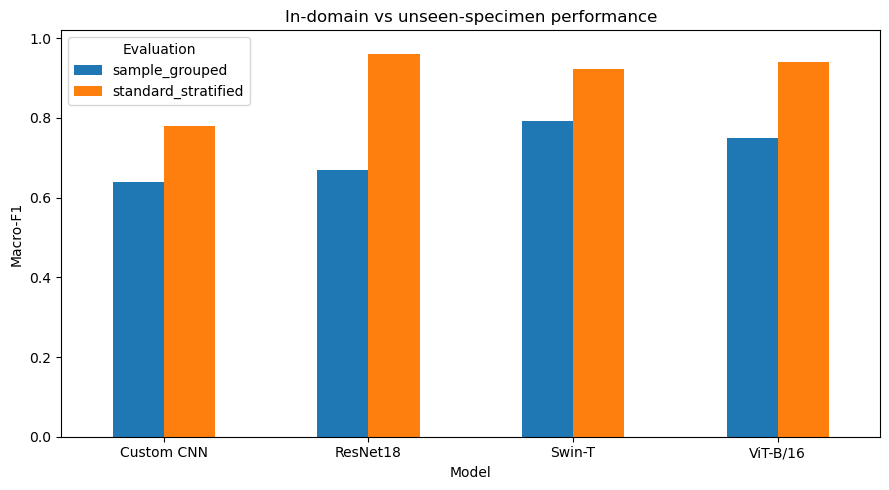

In [12]:
g=[]
for model in comparison.Model.unique():
    d=comparison[comparison.Model==model]
    if set(d.Evaluation)>={"standard_stratified","sample_grouped"}:
        a=float(d.loc[d.Evaluation=="standard_stratified","Macro F1"].iloc[0]);b=float(d.loc[d.Evaluation=="sample_grouped","Macro F1"].iloc[0])
        g.append({"Model":model,"Standard Macro-F1":a,"Unseen-sample Macro-F1":b,"Generalization gap":a-b})
gap=pd.DataFrame(g);display(gap.style.format({"Standard Macro-F1":"{:.4f}","Unseen-sample Macro-F1":"{:.4f}","Generalization gap":"{:.4f}"}))
gap.to_csv(RESULT_DIR/"generalization_gap_comparison.csv",index=False)
ax=comparison.pivot(index="Model",columns="Evaluation",values="Macro F1").plot(kind="bar",figsize=(9,5))
ax.set_ylim(0,1.02);ax.set_ylabel("Macro-F1");ax.set_title("In-domain vs unseen-specimen performance");plt.xticks(rotation=0);plt.tight_layout();plt.show()

## 13. Confusion matrices

Inspect the distribution of class-level errors for both Swin-T evaluation protocols. Aggregate metrics may conceal asymmetry between Bainite and Martensite misclassification rates.

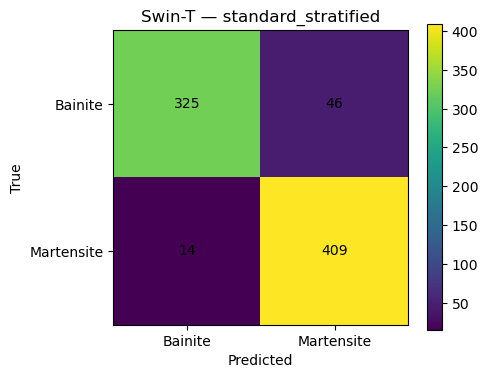

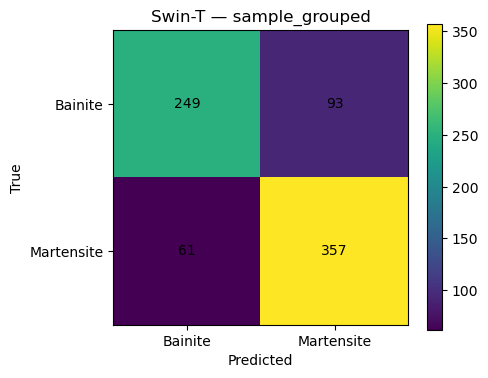

In [13]:
for name,r in results.items():
    cm=confusion_matrix(r["y"],r["pred"]);fig,ax=plt.subplots(figsize=(5,4));im=ax.imshow(cm)
    ax.set_xticks([0,1],["Bainite","Martensite"]);ax.set_yticks([0,1],["Bainite","Martensite"])
    ax.set_xlabel("Predicted");ax.set_ylabel("True");ax.set_title(f"Swin-T — {name}")
    for i in range(2):
        for j in range(2):ax.text(j,i,str(cm[i,j]),ha="center",va="center")
    fig.colorbar(im,ax=ax);fig.tight_layout();plt.show()

## 14. Consolidated results

Report test metrics, selected validation epochs, runtime and comparisons with earlier architectures. These values describe the **initial fixed-partition experiments**; robustness across alternative held-out specimens requires separate repeated-grouped evaluation.

In [14]:
print("="*88+"\nSWIN TRANSFORMER SUMMARY\n"+"="*88)
for _,r in swin_summary.iterrows():
    print(f"\n{r['Evaluation']}\n  Accuracy          : {r['Accuracy']:.4f}\n  Balanced Accuracy : {r['Balanced Accuracy']:.4f}\n  Macro-F1          : {r['Macro F1']:.4f}\n  ROC-AUC           : {r['ROC-AUC']:.4f}\n  Best val epoch    : {int(r['Best validation epoch'])}\n  Session runtime   : {r['Session runtime (min)']:.1f} min")
std=float(swin_summary.loc[swin_summary.Evaluation=="standard_stratified","Macro F1"].iloc[0])
unseen=float(swin_summary.loc[swin_summary.Evaluation=="sample_grouped","Macro F1"].iloc[0])
print("\nREFERENCE\n  ResNet18 standard       : 0.9608\n  ResNet18 unseen sample  : 0.6702\n  ViT-B/16 standard       : 0.9404\n  ViT-B/16 unseen sample  : 0.7497")
print(f"\nSWIN GENERALIZATION\n  Standard → unseen gap   : {std-unseen:.4f}\n  Δ vs ResNet unseen      : {unseen-.6702:+.4f}\n  Δ vs ViT unseen         : {unseen-.7497:+.4f}")
print("\nNEXT: Notebook 09 — domain-robust training\n"+"="*88)

SWIN TRANSFORMER SUMMARY

standard_stratified
  Accuracy          : 0.9244
  Balanced Accuracy : 0.9215
  Macro-F1          : 0.9236
  ROC-AUC           : 0.9848
  Best val epoch    : 19
  Session runtime   : 150.4 min

sample_grouped
  Accuracy          : 0.7974
  Balanced Accuracy : 0.7911
  Macro-F1          : 0.7932
  ROC-AUC           : 0.8728
  Best val epoch    : 3
  Session runtime   : 61.1 min

REFERENCE
  ResNet18 standard       : 0.9608
  ResNet18 unseen sample  : 0.6702
  ViT-B/16 standard       : 0.9404
  ViT-B/16 unseen sample  : 0.7497

SWIN GENERALIZATION
  Standard → unseen gap   : 0.1304
  Δ vs ResNet unseen      : +0.1230
  Δ vs ViT unseen         : +0.0435

NEXT: Notebook 09 — domain-robust training


## Interpretation and limitations

The Swin-T experiment adds a hierarchical transformer to the comparison of from-scratch convolutional, pretrained convolutional and transformer-based classifiers. The two fixed partitions address different questions: image-level discrimination within the collected dataset and transfer to physical specimens not represented during training.

Differences between architectures should not be treated as universal rankings. A single specimen-grouped partition cannot quantify how performance changes with the identities of the held-out specimens. Likewise, an observed change in Macro-F1 cannot on its own establish the effect of microscopy conditions or a particular microstructural mechanism.

The retained per-experiment results provide the basis for subsequent robustness analysis without changing this notebook's evaluation protocol.